## MaxHeapq Python Implementation

In [2]:
class MaxHeapq:
  """
  A class that implements a max heap data structure.

  Attributes
  ----------
  heap : list
    A list that represents the given max heap instance.
  heap_size : int
    The number of elements in the max heap.
  """

  def __init__(self):
    """
    Initializes an empty max heap with attributes heap and heap_size.

    Attributes
    ----------
    heap : list
      A list that represents the given max heap instance.
    heap_size : int
      The number of elements in the max heap.
    """

    self.heap = []
    self.heap_size = 0

  def left(self, n):
    """
    Computes the index of the left child of a node in the max heap.

    Parameters
    ----------
    n : int
      Index of the parent node.

    Returns
    ----------
    int
      Index of the left child of the given node.
    """
    return 2 * n + 1

  def right(self, n):
    """
    Computes the index of the right child of a node in the max heap.

    Parameters
    ----------
    n : int
      Index of the parent node.

    Returns
    ----------
    int
      Index of the right child of the given node.
    """

    return 2 * n + 2

  def parent(self, n):
    """
    Computes the index of the parent node of a given child node in the max heap.

    Parameters
    ----------
    n : int
      Index of the child node.

    Returns
    ----------
    int
      Index of the parent node of the given child node.
    """

    return (n - 1) // 2

  def max_key(self):
    """
    Returns the root's key (maximum) from the max heap.

    Returns
    ----------
    int
      The maximum key value in the max heap.
    """

    return self.heap[0]

  def increase_key(self, n, key):
    """
    Increases the key of a node at index `n` to a new value and maintains the max heap property.

    Parameters
    ----------
    n : int
      Index of the node whose key has to be increased.
    key : int
      The new key value.

    Raises
    ----------
    ValueError
      If the new key is smaller than the current key.
    """

    if key < self.heap[n]:
      raise ValueError("Error: New key is smaller than the current key. Cannot increase the value.")
    self.heap[n] = key

    # Maintain max heap property by swapping parent and child nodes upwards if needed
    while n > 0 and self.heap[self.parent(n)] < self.heap[n]:
      self.heap[n], self.heap[self.parent(n)] = self.heap[self.parent(n)], self.heap[n]
      n = self.parent(n)

  def heappush(self, key):
    """
    Adds a new key to the max heap and maintains the max heap property. If the key is a tuple, a tuple placeholder is used.

    Parameters
    ----------
    key : int or tuple
      The key to be added to the heap.
    """

    if isinstance(key, tuple):
      added_node = (-float("inf"), None)
    else:
      added_node = -float("inf")

    # Append a significantly small node to increase to the specified key value and
    # maintain the heap property using increase key()
    self.heap.append(added_node)
    self.increase_key(self.heap_size, key)
    self.heap_size += 1

  def heapify(self, n):
    """
    Maintains the max heap property by identifying the largest key
    in the parent-children relationship and moves the key to up.

    Parameters
    ----------
    n : int
      Index of the node to heapify.
    """

    left = self.left(n)
    right = self.right(n)
    heap = self.heap

    # Find the largest key among parent and children
    if left <= (self.heap_size - 1) and heap[left] > heap[n]:
      largest = left
    else:
      largest = n
    if right <= (self.heap_size - 1) and heap[right] > heap[largest]:
      largest = right

    # Swap the largest node with the parent and repeat the process if needed
    if largest != n:
      heap[n], heap[largest] = heap[largest], heap[n]
      self.heapify(largest)

  def heappop(self):
    """
    Removes and returns the root (maximum) key from the max heap.

    Returns
    ----------
    int
      The removed maximum key value.

    Raises
    ----------
    IndexError
      If the heap does not contain any keys.
    """

    if self.heap_size < 1:
      raise IndexError('No keys in the priority queue')
    max_key = self.max_key()

    # Replace root with last element and reduce heap size
    self.heap[0] = self.heap[-1]
    self.heap.pop()
    self.heap_size -= 1

    # Maintain heap property
    self.heapify(0)

    return max_key

## Maxheapq Testing

In [4]:
def is_max_heap(list_):
    """
    Checks whether a given list satisfies the max heap property.

    Parameters
    ----------
    list_ : list
        The input list.

    Returns
    -------
    bool
        True if the list is a max heap, False otherwise.
    """
    n = len(list_)
    # Calculate child keys of a list and check whether they are smaller than the parent
    for i in range(n // 2):
        left = 2 * i + 1
        right = 2 * i + 2

        # Check left child
        if left < n and list_[i] < list_[left]:
            return False
        # Check right child
        if right < n and list_[i] < list_[right]:
            return False
    return True

In [5]:
# Test the is_max_heap() function
try:
    assert is_max_heap([10, 5, 3, 2, 4, 0]) == True  # Valid max heap
    assert is_max_heap([10, 4, 3, 5, 1, 2]) == False # Not a valid max heap
    assert is_max_heap([-1, -2, -3, -4]) == True  # Valid max heap
    assert is_max_heap([1]) == True  # Valid max heap
    assert is_max_heap([]) == True  # Valid max heap

    print("The is_max_heap() function passed all tests ✅")
except AssertionError:
    print("The is_max_heap() function failed at least one test ❌")

The is_max_heap() function passed all tests ✅


In [6]:
print("Testing the MaxHeapq building algorithm...")

# Test 1: Empty Heap Tests
test1 = True
heap1 = MaxHeapq()

try:
    heap1.heappop()
    assert False
except IndexError:
    pass  # Should raise an IndexError

try:
    max_key = heap1.max_key()
    assert False
except IndexError:
    pass  # Should raise an IndexError
else:
    test1 = False

if test1:
    print("The MaxHeapq algorithm passed Test 1 ✅")
else:
    print("The MaxHeapq algorithm failed Test 1 ❌")


# Test 2: Single Element Heap
test2 = True
heap2 = MaxHeapq()
heap2.heappush(10)

try:
    assert heap2.max_key() == 10  # max_key() should return the only element
    assert is_max_heap(heap2.heap)  # Heap property should hold for single element
    assert heap2.heappop() == 10  # heappop() should return the element
    assert heap2.heap == []  # heap should be empty after removal
except AssertionError:
    test2 = False

if test2:
    print("The MaxHeapq algorithm passed Test 2 ✅")
else:
    print("The MaxHeapq algorithm failed Test 2 ❌")


# Test 3: Multiple Elements Heap
test3 = True
heap3 = MaxHeapq()
keys = [50, 20, 30, 10, 40]

for k in keys:
  heap3.heappush(k)

try:
    assert is_max_heap(heap3.heap)  # Heap property not maintained after multiple insertions
    assert heap3.max_key() == max(keys)  # max_key() should return the maximum value
except AssertionError:
    test3 = False

if test3:
    print("The MaxHeapq algorithm passed Test 3 ✅")
else:
    print("The MaxHeapq algorithm failed Test 3 ❌")


# Test 4: Increase Key
test4 = True
heap4 = MaxHeapq()

for v in [10, 20, 30]:
    heap4.heappush(v)

heap4.increase_key(2, 35)

try:
    heap4.increase_key(2, 35)
    assert heap4.max_key() == 35  # After increase, the new key should be at the root
    try:
        heap4.increase_key(2, 5)
        assert False  # Should raise ValueError when increasing to a lower value
    except ValueError:
        pass
except AssertionError:
    test4 = False

if test4:
    print("The MaxHeapq algorithm passed Test 4 ✅")
else:
    print("The MaxHeapq algorithm failed Test 4 ❌")


# Test 5: Duplicate Values
test5 = True
heap5 = MaxHeapq()

for v in [20, 20, 20]:
    heap5.heappush(v)

try:
    assert is_max_heap(heap5.heap)  # Heap property should hold with duplicate values
    assert heap5.max_key() == 20  # max_key should return the maximum value
except AssertionError:
    test5 = False

if test5:
    print("The MaxHeapq algorithm passed Test 5 ✅")
else:
    print("The MaxHeapq algorithm failed Test 5 ❌")


# Test 6: Negative Values
test6 = True
heap6 = MaxHeapq()

for v in [-10, -20, -5, -15]:
    heap6.heappush(v)
try:
    assert is_max_heap(heap6.heap)  # Heap property should hold for negative values
    assert heap6.max_key() == -5  # max_key should return the maximum value
except AssertionError:
    test6 = False

if test6:
    print("The MaxHeapq algorithm passed Test 6 ✅")
else:
    print("The MaxHeapq algorithm failed Test 6 ❌")

Testing the MaxHeapq building algorithm...
The MaxHeapq algorithm passed Test 1 ✅
The MaxHeapq algorithm passed Test 2 ✅
The MaxHeapq algorithm passed Test 3 ✅
The MaxHeapq algorithm passed Test 4 ✅
The MaxHeapq algorithm passed Test 5 ✅
The MaxHeapq algorithm passed Test 6 ✅


## Task Scheduler Python Implementation

In [8]:
class Task:
    """
    A class that creates a task with attributes: id, description, duration,
    dependencies, status, starting time, status, and priority.

    Attributes
    ----------
    id : int
      Unique identifier of the task.
    description : str
      Description of the task.
    duration : int
      Duration of the task in minutes.
    dependencies : list of int
      List of other task identifiers that must be completed before the task can be executed.
    start_time : int
      Specified starting time of the task in minutes.
    status : str
      Current status of the task. Default is "N", meaning the is not yet started.
    priority : any
      Priority of the task. Default is None.
    """

    def __init__(self, id, description, duration,
                 dependencies, start_time, status="N", priority=None):
      """
      Initializes a Task instance with attributes: id, description, duration,
      dependencies, status, starting time, status, and priority

      Attributes
      ----------
      id : int
        Unique identifier of the task.
      description : str
        Description of the task.
      duration : int
        Duration of the task in minutes.
      dependencies : list of int
        List of other task identifiers that must be completed before the task can be executed.
      start_time : int
        Specified starting time of the task in minutes.
      status : str
        Current status of the task. Default is "N", meaning the is not yet started.
      priority : any
        Priority of the task. Default is None.
      """
      self.id = id
      self.description = description
      self.duration = duration
      self.dependencies = dependencies
      self.start_time = start_time
      self.status = status
      self.priority = priority

    def __lt__(self, other):
      """
      Compares tasks based on their priority.

      Parameters
      ----------
      other : Task
        Another Task instance to compare the current task with.

      Returns
      ----------
      bool
        True if the current task has a lower priority than the other task. False otherwise.
      """
      return self.priority < other.priority

In [9]:
class TaskScheduler:
  """
  A scheduler class that calculates priorities of the input tasks and
  creates a schedule based on their dependencies, duration, and start time.

  Attributes
  ----------
  tasks : list
    A list of Task instances to be scheduled.
  priority_queue : MaxHeapq
    A max heap priority queue for managing task execution order.
  """

  # Possible status values.
  NOT_STARTED = 'N'
  IN_PRIORITY_QUEUE = 'I'
  COMPLETED = 'C'

  def __init__(self, tasks):
    """
    Initializes a TaskScheduler with a list of tasks and prepares an empty priority queue.

    Attributes
    ----------
    tasks : list
      A list of Task instances to be scheduled.
    priority_queue : MaxHeapq
      A max heap priority queue for managing task execution order.
    """
    self.tasks = tasks
    self.priority_queue = MaxHeapq()

  def compute_priority(self):
    """
    Calculates and assigns priorities to each task based on the number of dependent
    tasks and its duration. Number of dependent tasks are valued higher than duration.
    Fixed tasks receive a significant priority addition to ensure they are scheduled on time.
    """

    high_priority = 1000000

    # Sum all tasks that depend on the current task and extract duration to calculate priorities
    for task in self.tasks:
      dependent_count = sum(1 for t in self.tasks if task.id in t.dependencies)
      duration = task.duration

      # Number of dependent tasks are valued 5 times higher than duration
      alpha = 5
      beta = 1
      priority = alpha * dependent_count + beta * (duration // 5)

      # Fixed tasks receive much higher priority values
      if task.start_time is not None:
        task.priority = high_priority + priority
      else:
        task.priority = priority

  def print_self(self):
    """
    Prints the relevant information of all tasks: identifier, description, duration, dependencies
    (if applicable), start time (if applicable), and priority value.
    """

    self.compute_priority()
    print("📋 Here are tasks for the scheduler")
    for t in self.tasks:
      # Extract dependencies of a task and create a representative sting
      dependencies_string = ", ".join(f"TASK #{dep}" for dep in t.dependencies) if t.dependencies else "None"

      # Print task id, description, and duration in hours and minutes, if they exist
      print(f"➡️ TASK (ID: {t.id})\n"
            f"  📝 DESCRIPTION: {t.description}\n"
            f"  ⏳ DURATION: " + (f"{t.duration} minutes" if t.duration < 60
                              else f"{t.duration // 60} hours" +
                              (f" and {t.duration % 60} minutes" if t.duration % 60 else "")))
      # Print task dependencies of tasks with dependencies
      if len(t.dependencies) > 0:
        print(f"  ⚠️ DEPENDENCIES: {dependencies_string}")

      # Print task fixed time of tasks with fixed time
      if t.start_time is not None:
        print(f"  📌 FIXED TIME: {self.format_time(t.start_time)} - {self.format_time(t.start_time + t.duration)}")
          
      print(f"  🔻 PRIORITY: {t.priority}\n")

  def remove_dependency(self, id):
    """
    Removes a completed task (dependency) from a task.

    Parameters
    ----------
    id : int
        The identifier of the task to be removed from dependencies.
    """

    for t in self.tasks:
      if t.id != id and id in t.dependencies:
        t.dependencies.remove(id)

  def format_time(self, time):
    """
    Converts given time in minutes into an 'HH:MM' string.

    Parameters
    ----------
    time : int
        Time in minutes.

    Returns
    ----------
    str
        Time formatted in 'HH:MM'.
    """

    hours = time // 60
    minutes = time % 60
    return f"{hours}:{minutes:02d}"

  def get_tasks_ready(self, current_time, end_time):
    """
    Adds tasks to the priority queue if they are ready for execution.
    A task is ready if it has not been started, has no dependencies,
    and its duration fits within the available time window. Fixed time tasks are added
    only at their designated start time. If such tasks need to happen at a current time
    but have unresolved dependencies, they is marked as completed but not executed.

    Parameters
    ----------
    current_time : int
        The current time in minutes.
    end_time : int
        The ending time for scheduling in minutes.
    """

    remaining_time = end_time - current_time
    for task in self.tasks:
       # Deal only with tasks that have not been started
      if task.status == self.NOT_STARTED:
        # Add non-fixed-time tasks with the satisfied conditions to the priority queue
        if task.start_time is None and not task.dependencies and task.duration <= remaining_time:
          task.status = self.IN_PRIORITY_QUEUE
          self.priority_queue.heappush((task.priority, task))

        # Add fixed-time tasks with the satisfied conditions to the priority queue
        elif task.start_time is not None and task.start_time == current_time and task.duration <= remaining_time:
          if not task.dependencies:
            task.status = self.IN_PRIORITY_QUEUE
            self.priority_queue.heappush((task.priority, task))

          else:
            print(f"⚠️ You cannot do task '{task.description}' because it has dependencies tasks that have not been completed!")
            print("")
            task.status = self.COMPLETED

  def check_unscheduled_tasks(self):
    """
    Checks if there exist any unscheduled tasks.

    Returns
    ----------
    bool
        True if there exist unscheduled tasks. False otherwise.
    """

    for task in self.tasks:
      if task.status == self.NOT_STARTED:
          return True
    return False

  def run_task_scheduler(self, starting_time, end_time):
    """
    Runs the task scheduler, executing tasks based on priority while accounting for dependencies
    and time constraints. Updates the priority queue, executes tasks if they
    fit within the available time, and tracks scheduled and unscheduled tasks.

    Parameters
    ----------
    starting_time : int
        The start time of the scheduler in minutes.
    end_time : int
        The end time of the scheduler in minutes.
    """

    # Computes task priorities and ensures the scheduler has valid start and end times
    self.compute_priority()
    if end_time < starting_time:
        print("❗️ Scheduler's end time is earlier than its start time - cannot proceed.")
        return

    # Tracks the current time and when the last task finished
    current_time = starting_time
    last_finish_time = starting_time

    print("📆 Here is a schedule with the input tasks\n")

    # As long as there are unscheduled tasks or tasks in the priority queue, and
    # the current time has not exceeded the scheduler's end time, continue scheduling
    while (self.check_unscheduled_tasks() or self.priority_queue.heap_size > 0) and current_time < end_time:
      self.get_tasks_ready(current_time, end_time)

      # Find the next fixed task's start time if there exist any unscheduled ones
      fixed_start_times = [
        t.start_time for t in self.tasks
        if t.start_time is not None
        and t.status in [self.NOT_STARTED, self.IN_PRIORITY_QUEUE]
        and t.start_time > current_time
      ]
      next_fixed_time = min(fixed_start_times) if fixed_start_times else None

      if self.priority_queue.heap_size > 0:
        # Look at the highest priority task in the priority queue
        potential_priority, potential_task = self.priority_queue.max_key()

        # Check if non-fixed-time task can finish before next fixed task starts
        if next_fixed_time is None or (current_time + potential_task.duration) < next_fixed_time:
          # Check if executing the task would go over the schedule ending time
          if current_time + potential_task.duration > end_time:
            break

          _, task = self.priority_queue.heappop() # Remove highest priority task
          print(f"📝 TASK: {task.description}")
          print(f"  🫡 START: {self.format_time(current_time)}")
          print(f"  ⏳ DURATION: " + (f"{task.duration} minutes" if task.duration < 60
                    else f"{task.duration // 60} hours" +
                    (f" and {task.duration % 60} minutes" if task.duration % 60 else "")))
          current_time += task.duration
          last_finish_time = current_time
          print(f"  ✅ FINISH: {self.format_time(current_time)}")
          print(f"  🔻 PRIORITY: {task.priority}\n")

          self.remove_dependency(task.id) # Remove task from dependency lists
          task.status = self.COMPLETED
          continue

      if next_fixed_time is not None:
        # Print free time if the next fixed task fits in the schedule
        if next_fixed_time <= end_time:
          free_time = next_fixed_time - current_time
          print(f"🎉 FREE TIME")
          print(f"  😎 START: {self.format_time(current_time)}")
          print(f" ⏳ DURATION: " + (f"{free_time} minutes" if free_time < 60
                    else f"{free_time // 60} hours" +
                    (f" and {free_time % 60} minutes" if free_time % 60 else "")))
          print(f"  😞 FINISH: {self.format_time(next_fixed_time)}\n")
          current_time = next_fixed_time
        else:
          break
      else:
        # If no tasks are available, increment time by 1 minute
        current_time += 1

    # Print total time taken to execute tasks
    total_time = last_finish_time - starting_time
    print(f"🏁 TOTAL TIME: {total_time // 60} hours"
          + (f" and {total_time % 60:02d} minutes" if total_time % 60 else ""))

    # Print tasks that could not be scheduled
    incomplete_tasks = [t for t in self.tasks if t.status != self.COMPLETED]
    if incomplete_tasks:
      print("--------------------------------------")
      print("😯 The following tasks could not be completed because the available time was exceeded:")
      for task in incomplete_tasks:
        print(f"   ➡️ TASK #{task.id}: {task.description}")

In [10]:
def time_to_minutes(time_str):
    """
    Converts a time string to minutes.

    Parameters:
    ----------
      time_str : str
        Time string in "HH:MM" format.

    Returns:
    ----------
      int
        Total minutes.
    """

    hours, minutes = time_str.split(":")
    return int(hours) * 60 + int(minutes)

In [11]:
# Testing the time conversion function
try:
    assert time_to_minutes("00:00") == 0
    assert time_to_minutes("00:01") == 1
    assert time_to_minutes("01:00") == 60
    assert time_to_minutes("12:30") == 750
    assert time_to_minutes("23:59") == 1439

    print("The time_to_minutes() function passed all tests ✅")
except AssertionError:
    print("The time_to_minutes() function failed at least one test ❌")

The time_to_minutes() function passed all tests ✅


## Task Scheduler Testing

### Prioritization Check 

In [14]:
# List of tasks with increasing number of dependencies, decreasing duration, 
# and no time windows to check prioritization
priority_check_tasks = [
  Task(id=0, description='Task 1',
        duration=80, dependencies=[], start_time=None),
  Task(id=1, description='Task 2',
        duration=70, dependencies=[0], start_time=None),
  Task(id=2, description='Task 3',
        duration=60, dependencies=[0, 1], start_time=None),
  Task(id=3, description='Task 4',
        duration=50, dependencies=[0, 1, 2], start_time=None),
  Task(id=4, description='Task 5',
        duration=40, dependencies=[0, 1, 2, 3], start_time=None),
  Task(id=5, description='Task 6',
        duration=30, dependencies=[0, 1, 2, 3, 4], start_time=None),
  Task(id=6, description='Task 7',
        duration=20, dependencies=[0, 1, 2, 3, 4, 5], start_time=None),
  Task(id=7, description='Task 8',
        duration=10, dependencies=[0, 1, 2, 3, 4, 5, 6], start_time=None)
       ]

# Run the scheduler
task_scheduler = TaskScheduler(priority_check_tasks)
start_time = time_to_minutes("8:00")
end_time = time_to_minutes("22:00")
task_scheduler.run_task_scheduler(start_time, end_time)

📆 Here is a schedule with the input tasks

📝 TASK: Task 1
  🫡 START: 8:00
  ⏳ DURATION: 1 hours and 20 minutes
  ✅ FINISH: 9:20
  🔻 PRIORITY: 51

📝 TASK: Task 2
  🫡 START: 9:20
  ⏳ DURATION: 1 hours and 10 minutes
  ✅ FINISH: 10:30
  🔻 PRIORITY: 44

📝 TASK: Task 3
  🫡 START: 10:30
  ⏳ DURATION: 1 hours
  ✅ FINISH: 11:30
  🔻 PRIORITY: 37

📝 TASK: Task 4
  🫡 START: 11:30
  ⏳ DURATION: 50 minutes
  ✅ FINISH: 12:20
  🔻 PRIORITY: 30

📝 TASK: Task 5
  🫡 START: 12:20
  ⏳ DURATION: 40 minutes
  ✅ FINISH: 13:00
  🔻 PRIORITY: 23

📝 TASK: Task 6
  🫡 START: 13:00
  ⏳ DURATION: 30 minutes
  ✅ FINISH: 13:30
  🔻 PRIORITY: 16

📝 TASK: Task 7
  🫡 START: 13:30
  ⏳ DURATION: 20 minutes
  ✅ FINISH: 13:50
  🔻 PRIORITY: 9

📝 TASK: Task 8
  🫡 START: 13:50
  ⏳ DURATION: 10 minutes
  ✅ FINISH: 14:00
  🔻 PRIORITY: 2

🏁 TOTAL TIME: 6 hours


### Randomization Testing

In [16]:
# Shuffled list of previously created tasks 
shuffled_tasks = [
  Task(id=5, description='Task 6',
    duration=30, dependencies=[0, 1, 2, 3, 4], start_time=None),
  Task(id=1, description='Task 2',
        duration=70, dependencies=[0], start_time=None),
  Task(id=3, description='Task 4',
        duration=50, dependencies=[0, 1, 2], start_time=None),
  Task(id=7, description='Task 8',
    duration=10, dependencies=[0, 1, 2, 3, 4, 5, 6], start_time=None),
  Task(id=4, description='Task 5',
        duration=40, dependencies=[0, 1, 2, 3], start_time=None),
  Task(id=2, description='Task 3',
    duration=60, dependencies=[0, 1], start_time=None),
  Task(id=0, description='Task 1',
    duration=80, dependencies=[], start_time=None),
  Task(id=6, description='Task 7',
        duration=20, dependencies=[0, 1, 2, 3, 4, 5], start_time=None)
       ]

# Run the scheduler
task_scheduler = TaskScheduler(shuffled_tasks)
start_time = time_to_minutes("8:00")
end_time = time_to_minutes("22:00")
task_scheduler.run_task_scheduler(start_time, end_time)

📆 Here is a schedule with the input tasks

📝 TASK: Task 1
  🫡 START: 8:00
  ⏳ DURATION: 1 hours and 20 minutes
  ✅ FINISH: 9:20
  🔻 PRIORITY: 51

📝 TASK: Task 2
  🫡 START: 9:20
  ⏳ DURATION: 1 hours and 10 minutes
  ✅ FINISH: 10:30
  🔻 PRIORITY: 44

📝 TASK: Task 3
  🫡 START: 10:30
  ⏳ DURATION: 1 hours
  ✅ FINISH: 11:30
  🔻 PRIORITY: 37

📝 TASK: Task 4
  🫡 START: 11:30
  ⏳ DURATION: 50 minutes
  ✅ FINISH: 12:20
  🔻 PRIORITY: 30

📝 TASK: Task 5
  🫡 START: 12:20
  ⏳ DURATION: 40 minutes
  ✅ FINISH: 13:00
  🔻 PRIORITY: 23

📝 TASK: Task 6
  🫡 START: 13:00
  ⏳ DURATION: 30 minutes
  ✅ FINISH: 13:30
  🔻 PRIORITY: 16

📝 TASK: Task 7
  🫡 START: 13:30
  ⏳ DURATION: 20 minutes
  ✅ FINISH: 13:50
  🔻 PRIORITY: 9

📝 TASK: Task 8
  🫡 START: 13:50
  ⏳ DURATION: 10 minutes
  ✅ FINISH: 14:00
  🔻 PRIORITY: 2

🏁 TOTAL TIME: 6 hours


### Daily Tasks and Schedule of A Typical Minervan

In [18]:
# Daily tasks of a typical Minervan
daily_tasks = [
  Task(id=0, description='Wake up',
        duration=10, dependencies=[], start_time=time_to_minutes("8:00")),
  Task(id=1, description='Eat breakfast',
        duration=30, dependencies=[0], start_time=None),
  Task(id=2, description='Get fresh bread',
        duration=20, dependencies=[0], start_time=time_to_minutes("10:00")),
  Task(id=3, description='Complete CS110 PCW',
        duration=120, dependencies=[0, 1], start_time=None),
  Task(id=4, description='Eat lunch',
        duration=30, dependencies=[0, 2], start_time=None),
  Task(id=5, description='Cheongnyangi market',
        duration=60, dependencies=[0, 3], start_time=None),
  Task(id=6, description='Attend CS110 class',
        duration=90, dependencies=[0, 3], start_time=time_to_minutes("18:00")),
  Task(id=7, description='Get bungeoppang',
        duration=15, dependencies=[0, 6], start_time=None)
       ]

task_scheduler = TaskScheduler(daily_tasks)

In [19]:
# Run the scheduler with specified start and end times
start_time = time_to_minutes("8:00")
end_time = time_to_minutes("22:00")
task_scheduler.run_task_scheduler(start_time, end_time)

📆 Here is a schedule with the input tasks

📝 TASK: Wake up
  🫡 START: 8:00
  ⏳ DURATION: 10 minutes
  ✅ FINISH: 8:10
  🔻 PRIORITY: 1000037

📝 TASK: Eat breakfast
  🫡 START: 8:10
  ⏳ DURATION: 30 minutes
  ✅ FINISH: 8:40
  🔻 PRIORITY: 11

🎉 FREE TIME
  😎 START: 8:40
 ⏳ DURATION: 1 hours and 20 minutes
  😞 FINISH: 10:00

📝 TASK: Get fresh bread
  🫡 START: 10:00
  ⏳ DURATION: 20 minutes
  ✅ FINISH: 10:20
  🔻 PRIORITY: 1000009

📝 TASK: Complete CS110 PCW
  🫡 START: 10:20
  ⏳ DURATION: 2 hours
  ✅ FINISH: 12:20
  🔻 PRIORITY: 34

📝 TASK: Cheongnyangi market
  🫡 START: 12:20
  ⏳ DURATION: 1 hours
  ✅ FINISH: 13:20
  🔻 PRIORITY: 12

📝 TASK: Eat lunch
  🫡 START: 13:20
  ⏳ DURATION: 30 minutes
  ✅ FINISH: 13:50
  🔻 PRIORITY: 6

🎉 FREE TIME
  😎 START: 13:50
 ⏳ DURATION: 4 hours and 10 minutes
  😞 FINISH: 18:00

📝 TASK: Attend CS110 class
  🫡 START: 18:00
  ⏳ DURATION: 1 hours and 30 minutes
  ✅ FINISH: 19:30
  🔻 PRIORITY: 1000023

📝 TASK: Get bungeoppang
  🫡 START: 19:30
  ⏳ DURATION: 15 minutes


## Complexity Analysis

In [21]:
# Import necessary libraries
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [22]:
class TaskSchedulerNoPrint(TaskScheduler):
    """
    A no-print scheduler class that calculates priorities of the input tasks and
    creates a schedule based on their dependencies, duration, and start time. Inherits
    all methods of TaskScheduler and modifies the run_task_scheduler() to not print
    any output.

    Attributes
    ----------
    tasks : list
      A list of Task instances to be scheduled.
    priority_queue : MaxHeapq
      A max heap priority queue for managing task execution order.
    """

    def get_tasks_ready(self, current_time, end_time):
      """
      Adds tasks to the priority queue if they are ready for execution.
      A task is ready if it has not been started, has no dependencies,
      and its duration fits within the available time window. Fixed time tasks are added
      only at their designated start time. If such tasks need to happen at a current time
      but have unresolved dependencies, they is marked as completed but not executed.

      Parameters
      ----------
      current_time : int
          The current time in minutes.
      end_time : int
          The ending time for scheduling in minutes.
      """

      remaining_time = end_time - current_time
      for task in self.tasks:
        # Deal only with tasks that have not been started
        if task.status == self.NOT_STARTED:
          # Add non-fixed-time tasks with the satisfied conditions to the priority queue
          if task.start_time is None and not task.dependencies and task.duration <= remaining_time:
            task.status = self.IN_PRIORITY_QUEUE
            self.priority_queue.heappush((task.priority, task))

          # Add fixed-time tasks with the satisfied conditions to the priority queue
          elif task.start_time is not None and task.start_time == current_time and task.duration <= remaining_time:
            if not task.dependencies:
              task.status = self.IN_PRIORITY_QUEUE
              self.priority_queue.heappush((task.priority, task))

            else:
              task.status = self.COMPLETED

    def run_task_scheduler(self, starting_time, end_time):
        """
        Runs the task scheduler silently, executing tasks based on priority while accounting for dependencies
        and time constraints. Updates the priority queue, executes tasks if they
        fit within the available time, and tracks scheduled and unscheduled tasks.
        This method does not print any output.

        Parameters
        ----------
        starting_time : int
            The start time of the scheduler in minutes.
        end_time : int
            The end time of the scheduler in minutes.
        """

        # Computes task priorities and ensures the scheduler has valid start and end times
        self.compute_priority()
        if end_time < starting_time:
            return

        # Tracks the current time and when the last task finished
        current_time = starting_time
        last_finish_time = starting_time

        # As long as there are unscheduled tasks or tasks in the priority queue, and
        # the current time has not exceeded the scheduler's end time, continue scheduling
        while (self.check_unscheduled_tasks() or self.priority_queue.heap_size > 0) and current_time < end_time:
            self.get_tasks_ready(current_time, end_time)

            # Find the next fixed task's start time if there exist any unscheduled ones
            fixed_start_times = [
                t.start_time for t in self.tasks
                if t.start_time is not None
                and t.status in [self.NOT_STARTED, self.IN_PRIORITY_QUEUE]
                and t.start_time > current_time
            ]
            next_fixed_time = min(fixed_start_times) if fixed_start_times else None

            if self.priority_queue.heap_size > 0:
                # Look at the highest priority task in the priority queue
                potential_priority, potential_task = self.priority_queue.max_key()

                # Check if non-fixed-time task can finish before next fixed task starts
                if next_fixed_time is None or (current_time + potential_task.duration) < next_fixed_time:
                    # Check if executing the task would go over the schedule ending time
                    if current_time + potential_task.duration > end_time:
                        break

                    _, task = self.priority_queue.heappop()   # Remove highest priority task
                    current_time += task.duration
                    last_finish_time = current_time

                    self.remove_dependency(task.id)   # Remove task from dependency lists
                    task.status = self.COMPLETED
                    continue

            if next_fixed_time is not None:
                # Calculate free time if the next fixed task fits in the schedule
                if next_fixed_time <= end_time:
                    current_time = next_fixed_time
                else:
                    break
            else:
                current_time += 1

        # Calculate total time taken to execute tasks
        total_time = last_finish_time - starting_time

        # Find tasks that could not be scheduled
        incomplete_tasks = [t for t in self.tasks if t.status != self.COMPLETED]
        return

## Input Generators

In [24]:
def generate_best_case(num_tasks):
    """
    Generate a list of best-case tasks with no dependencies, no start times, and duration
    in descending.

    Parameters
    ----------
    num_tasks : int
        Number of tasks to generate.
    end_time : int
        The end time of the scheduler in minutes.

    Returns
    ----------
    tasks : list
      A list of best-case tasks.
    """
    tasks = []

    # Create best-case tasks specified by num_tasks
    for i in range(num_tasks):
        id = i + 1
        dependencies = []
        duration = num_tasks - i
        start_time = None
        description = f"Task {id}"

        task = Task(id, description, duration, dependencies, start_time)
        tasks.append(task)

    return tasks

In [25]:
def generate_worst_case(num_tasks):
    """
    Generate a list of worst-case tasks with maximized dependencies, duration set to a con to start times.

    Parameters
    ----------
    num_tasks : int
        Number of tasks to generate.
    end_time : int
        The end time of the scheduler in minutes.

    Returns
    ----------
    tasks : list
      A list of best-case tasks.
    """
    
    tasks = []
    for i in range(num_tasks):
        task_id = i + 1
        dependencies = list(range(1, task_id)) if task_id > 1 else []
        duration = 1  
        start_time = None
        description = f"Task {task_id}"

        task = Task(task_id, description, duration, dependencies, start_time)
        tasks.append(task)

    return tasks

In [26]:
def generate_average_case(num_tasks):
    """
    Generate a list of avergae-case tasks with maximized dependencies, duration set to a con to start times.

    Parameters
    ----------
    num_tasks : int
        Number of tasks to generate.
    end_time : int
        The end time of the scheduler in minutes.

    Returns
    ----------
    tasks : list
      A list of best-case tasks.
    """
    
    tasks = []
    for i in range(num_tasks):
        task_id = i + 1
        
        if task_id > 1:
            dependencies = [j for j in range(1, task_id) if random.random() < 0.3]
        else:
            dependencies = []
        
        duration = random.randint(5, 60)
        
        if random.random() < 0.5:
            start_time = None
        else:
            start_time = random.randint(0, int(max(0, end_time - duration)))
        
        description = f"Task {task_id}"
        
        task = Task(task_id, description, duration, dependencies, start_time)
        tasks.append(task)
        
    return tasks

## Best-Case Complexity

In [28]:
# Number of tasks
num_tasks = list(range(1, 1002, 100))

# Store average runtimes for each input size
average_run_times_best = []

# Number of trials per input size
trials = 50

# Warm up the CPU
for i in range(1000000):
  a = i*i

# Calculate runtimes for different numbers of best-case tasks 50 times and average out
for n in num_tasks:
    run_times = []
    for _ in range(trials):
        tasks = generate_best_case(n)
        scheduler = TaskSchedulerNoPrint(tasks)

        start_time = time.time()
        scheduler.run_task_scheduler(time_to_minutes("00:00"), time_to_minutes("23:59"))
        end_time = time.time()

        run_times.append(end_time - start_time)

    # Calculate average runtimes for each input size
    avg_runtime = np.mean(run_times)
    average_run_times_best.append(avg_runtime)

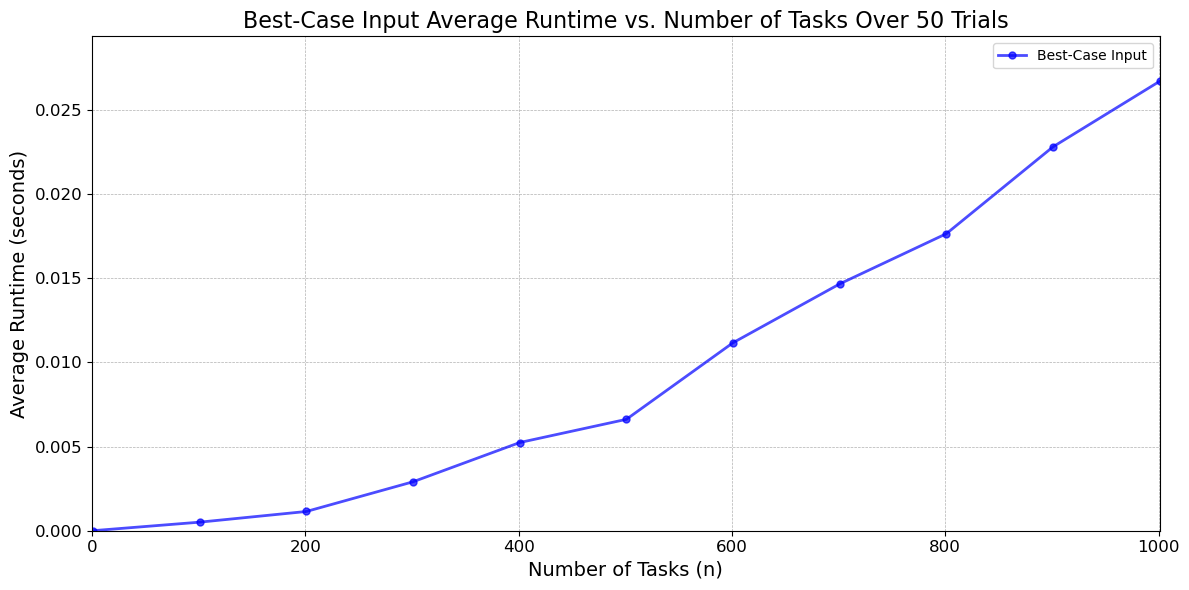

In [29]:
# Plot and show complexity of best-case input
plt.figure(figsize=(12, 6))
plt.plot(num_tasks, average_run_times_best, marker='o', linestyle='-', color='b',
         markersize=5, label=f"Best-Case Input", alpha=0.7, linewidth=2)
plt.xlabel("Number of Tasks (n)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Best-Case Input Average Runtime vs. Number of Tasks Over {trials} Trials", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks))
plt.ylim(0, max(average_run_times_best) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

### Best-Case Complexity Verification

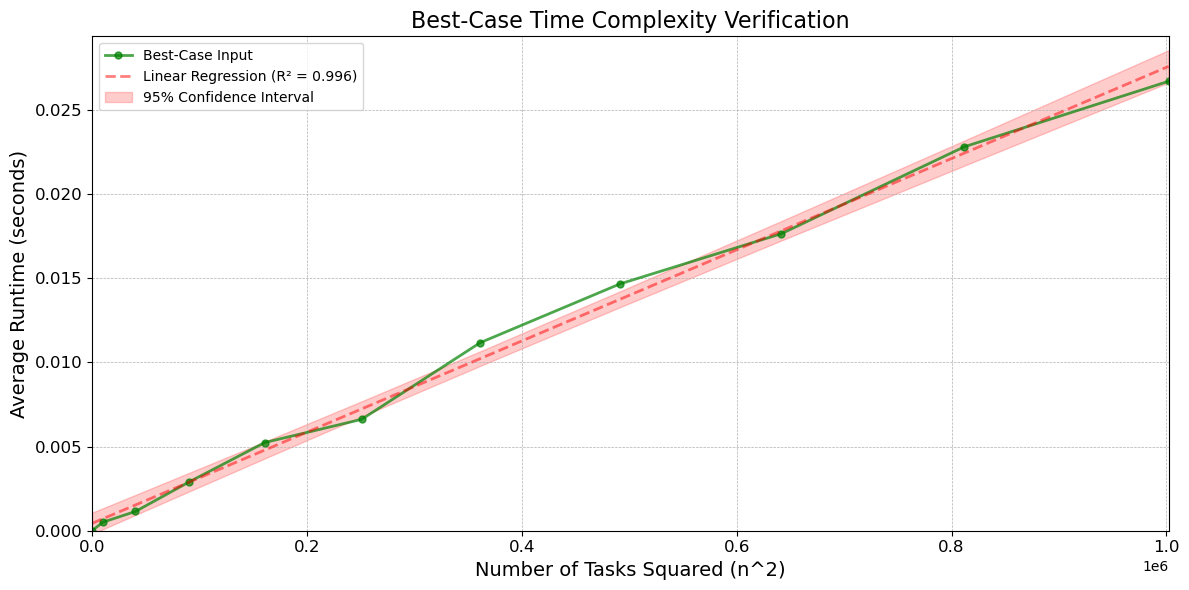

In [31]:
# Transform x-values to n^2 scale
num_tasks = np.array(list(range(1, 1002, 100)))
num_tasks_squared_3 = num_tasks**2

# Fit the linear regression model
X = sm.add_constant(num_tasks_squared_3)
model = sm.OLS(average_run_times_best, X).fit()
predictions = model.get_prediction(X)
pred_summary = predictions.summary_frame(alpha=0.05)

# Regression line and confidence intervals
regression_line = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']

# Calculate r-squared
r_squared = model.rsquared

# Plot the average-case input complexity and regression line with its confidence interval
plt.figure(figsize=(12, 6))
plt.plot(num_tasks_squared_3, average_run_times_best, marker='o', linestyle='-', color='green',
         markersize=5, label="Best-Case Input", alpha=0.7, linewidth=2)
plt.plot(num_tasks_squared_3, regression_line, color='r', linestyle='--', linewidth=2, alpha=0.5,
         label=f"Linear Regression (R² = {r_squared:.3f})")
plt.fill_between(num_tasks_squared_3, ci_lower, ci_upper, color='r', alpha=0.2,
                 label="95% Confidence Interval")
plt.xlabel("Number of Tasks Squared (n^2)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Best-Case Time Complexity Verification", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks_squared_3))
plt.ylim(0, max(average_run_times_best) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

## Worst-Case Complexity

In [33]:
# Number of tasks
num_tasks = list(range(1, 1002, 100))

# Store average runtimes for each input size
average_run_times_worst = []

# Number of trials per input size
trials = 25

# Warm up the CPU
for i in range(1000000):
  a = i*i

# Calculate runtimes for different numbers of best-case tasks 50 times and average out
for n in num_tasks:
    run_times = []
    for _ in range(trials):
        tasks = generate_worst_case(n)
        scheduler = TaskSchedulerNoPrint(tasks)

        start_time = time.time()
        scheduler.run_task_scheduler(time_to_minutes("00:00"), time_to_minutes("23:59"))
        end_time = time.time()

        run_times.append(end_time - start_time)

    # Calculate average runtimes for each input size
    avg_runtime = np.mean(run_times)
    average_run_times_worst.append(avg_runtime)

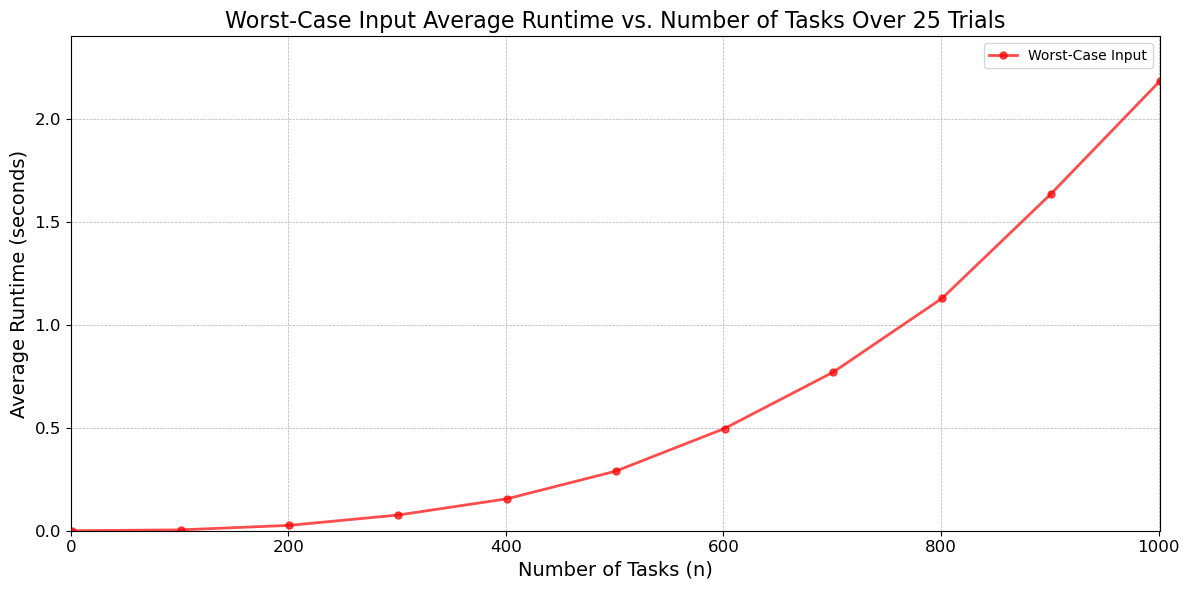

In [34]:
# Plot and show complexity of worst-case input
plt.figure(figsize=(12, 6))
plt.plot(num_tasks, average_run_times_worst, marker='o', linestyle='-', color='r',
         markersize=5, label=f"Worst-Case Input", alpha=0.7, linewidth=2)
plt.xlabel("Number of Tasks (n)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Worst-Case Input Average Runtime vs. Number of Tasks Over {trials} Trials", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks))
plt.ylim(0, max(average_run_times_worst) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

### Worst-Case Complexity Verification

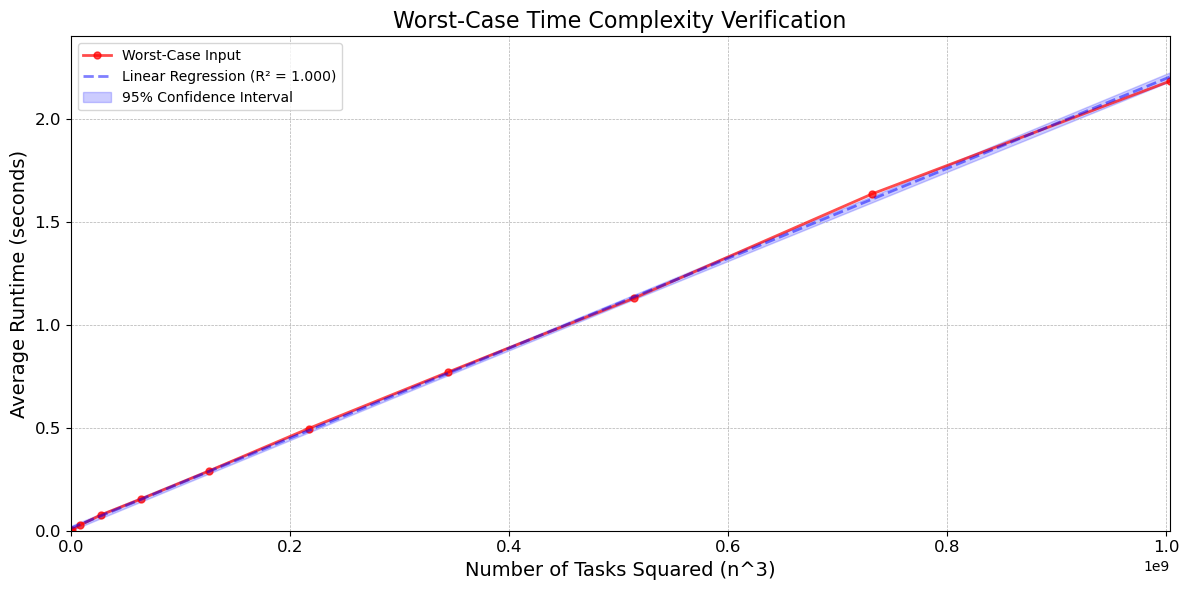

In [36]:
# Transform x-values to n^3 scale
num_tasks = np.array(list(range(1, 1002, 100)))
num_tasks_squared_3 = num_tasks**3

# Fit the linear regression model
X = sm.add_constant(num_tasks_squared_3)
model = sm.OLS(average_run_times_worst, X).fit()
predictions = model.get_prediction(X)
pred_summary = predictions.summary_frame(alpha=0.05)

# Regression line and confidence intervals
regression_line = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']

# Calculate r-squared
r_squared = model.rsquared

# Plot the average-case input complexity and regression line with its confidence interval
plt.figure(figsize=(12, 6))
plt.plot(num_tasks_squared_3, average_run_times_worst, marker='o', linestyle='-', color='red',
         markersize=5, label="Worst-Case Input", alpha=0.7, linewidth=2)
plt.plot(num_tasks_squared_3, regression_line, color='b', linestyle='--', linewidth=2, alpha=0.5,
         label=f"Linear Regression (R² = {r_squared:.3f})")
plt.fill_between(num_tasks_squared_3, ci_lower, ci_upper, color='b', alpha=0.2,
                 label="95% Confidence Interval")
plt.xlabel("Number of Tasks Squared (n^3)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Worst-Case Time Complexity Verification", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks_squared_3))
plt.ylim(0, max(average_run_times_worst) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

## Average-Case Complexity

In [38]:
# Number of tasks
num_tasks = list(range(1, 1002, 100))

# Store average runtimes for each input size
average_run_times_average = []

# Number of trials per input size
trials = 50

# Warm up the CPU
for i in range(1000000):
  a = i*i

# Calculate runtimes for different numbers of best-case tasks 50 times and average out
for n in num_tasks:
    run_times = []
    for _ in range(trials):
        tasks = generate_average_case(n)
        scheduler = TaskSchedulerNoPrint(tasks)

        start_time = time.time()
        scheduler.run_task_scheduler(time_to_minutes("00:00"), time_to_minutes("23:59"))
        end_time = time.time()

        run_times.append(end_time - start_time)

    # Calculate average runtimes for each input size
    avg_runtime = np.mean(run_times)
    average_run_times_average.append(avg_runtime)

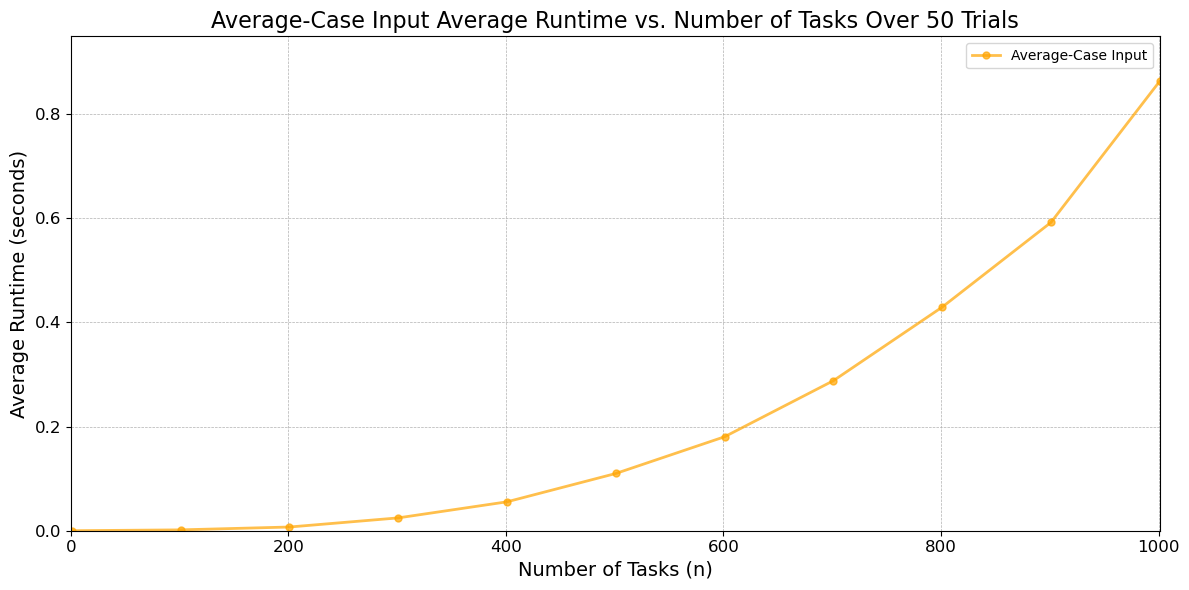

In [39]:
# Plot and show complexity of average-case input
plt.figure(figsize=(12, 6))
plt.plot(num_tasks, average_run_times_average, marker='o', linestyle='-', color='orange',
         markersize=5, label=f"Average-Case Input", alpha=0.7, linewidth=2)
plt.xlabel("Number of Tasks (n)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Average-Case Input Average Runtime vs. Number of Tasks Over {trials} Trials", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks))
plt.ylim(0, max(average_run_times_average) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

### Average-Case Complexity Verification

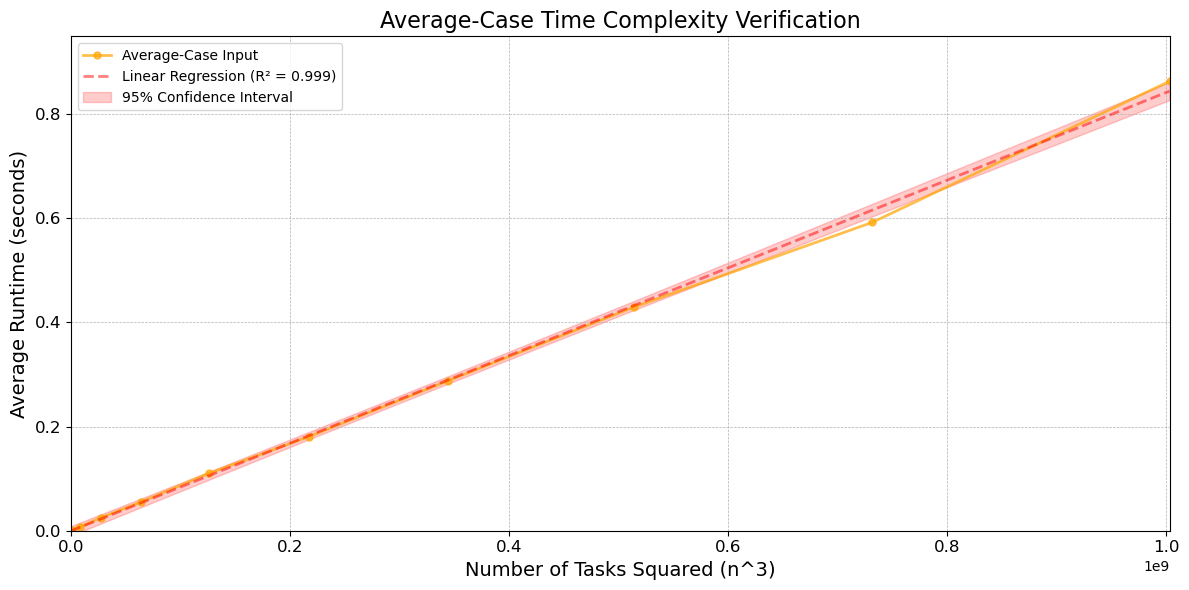

In [41]:
# Transform x-values to n^3 scale
num_tasks = np.array(list(range(1, 1002, 100)))
num_tasks_squared_3 = num_tasks**3

# Fit the linear regression model
X = sm.add_constant(num_tasks_squared_3)
model = sm.OLS(average_run_times_average, X).fit()
predictions = model.get_prediction(X)
pred_summary = predictions.summary_frame(alpha=0.05)

# Regression line and confidence intervals
regression_line = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']

# Calculate r-squared
r_squared = model.rsquared

# Plot the average-case input complexity and regression line with its confidence interval
plt.figure(figsize=(12, 6))
plt.plot(num_tasks_squared_3, average_run_times_average, marker='o', linestyle='-', color='orange',
         markersize=5, label="Average-Case Input", alpha=0.7, linewidth=2)
plt.plot(num_tasks_squared_3, regression_line, color='r', linestyle='--', linewidth=2, alpha=0.5,
         label=f"Linear Regression (R² = {r_squared:.3f})")
plt.fill_between(num_tasks_squared_3, ci_lower, ci_upper, color='r', alpha=0.2,
                 label="95% Confidence Interval")
plt.xlabel("Number of Tasks Squared (n^3)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title(f"Average-Case Time Complexity Verification", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks_squared_3))
plt.ylim(0, max(average_run_times_average) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

### All Input Type Complexity 

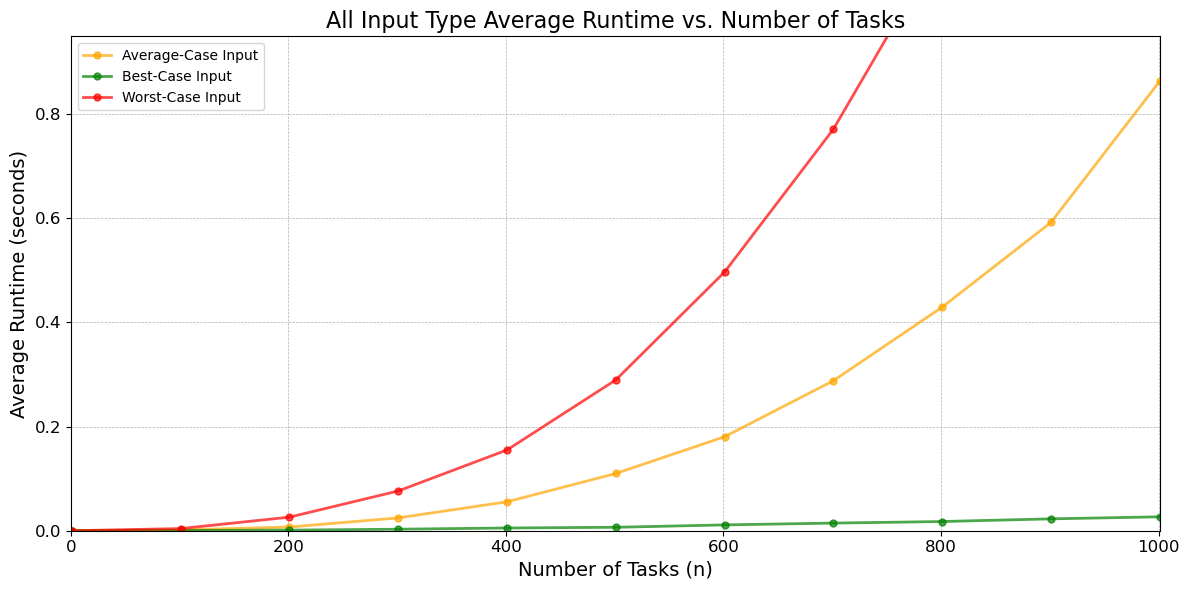

In [43]:
# Plot and show complexities of all input types
plt.figure(figsize=(12, 6))
plt.plot(num_tasks, average_run_times_average, marker='o', linestyle='-', color='orange',
         markersize=5, label=f"Average-Case Input", alpha=0.7, linewidth=2)
plt.plot(num_tasks, average_run_times_best, marker='o', linestyle='-', color='g',
         markersize=5, label=f"Best-Case Input", alpha=0.7, linewidth=2)
plt.plot(num_tasks, average_run_times_worst, marker='o', linestyle='-', color='r',
         markersize=5, label=f"Worst-Case Input", alpha=0.7, linewidth=2)
plt.xlabel("Number of Tasks (n)", fontsize=14)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.title("All Input Type Average Runtime vs. Number of Tasks", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, max(num_tasks))
plt.ylim(0, max(average_run_times_average) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()